# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 06: Árvores de Decisão e k-Means**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
url = "https://gist.githubusercontent.com/marcelovca90/de69333ef1e36f6ce4671e387f820f34/raw/29d61f2789c51a84144192a8127c5b041fa8bca2/wifi_localization.txt"

column_names = [ "AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7", "Room" ]

df = pd.read_csv(url, sep="\t", header=None, names=column_names)

X = df.drop(columns=["Room"]).values
y = df["Room"].values

feature_names = df.columns[:-1].tolist()

df.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### <font color='#2D9CDB'>Q1) O Wireless Indoor Localization [[1]](https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization)[[2]](https://archive-beta.ics.uci.edu/dataset/422/wireless+indoor+localization) é um conjunto de dados amplamente utilizado em pesquisas sobre posicionamento indoor e redes sem fio. Pesquise brevemente sobre esse dataset e descreva, em um único parágrafo, qual é o problema que ele busca resolver, quais informações são registradas em cada amostra, o significado dos valores RSSI (Received Signal Strength Indicator) e por que essa base de dados pode ser utilizada tanto em problemas de classificação quanto de clusterização.</font>

Foi desenvolvido para estudar o problema de localização indoor utilizando sinais de redes Wi-Fi. O objetivo é determinar em qual ambiente ou sala uma pessoa ou dispositivo se encontra a partir da intensidade dos sinais recebidos de diferentes pontos de acesso sem fio. Cada amostra do conjunto de dados registra os valores RSSI medidos por sete pontos de acesso Wi-Fi distintos (AP1 a AP7), além do identificador da sala correspondente. Os valores RSSI representam a potência do sinal recebido em dbm. Essa base pode ser utilizada em problemas de classificação porque possui rótulos indicando a sala correta de cada amostra, permitindo treinar modelos supervisionados para prever a localização. Também pode ser usada em clusterização pois os padrões de intensidade dos sinais tendem a formar agrupamentos naturais associados às diferentes salas, possibilitando a descoberta desses grupos sem a utilização dos rótulos.

### <font color='#2D9CDB'>Q2) Utilizando o dataset Wireless Indoor Localization já carregado, informe a quantidade total de amostras, o número de atributos, o número de classes e os identificadores das salas presentes na base de dados. Em seguida, apresente uma tabela contendo as cinco primeiras amostras do conjunto de dados. Com base nos resultados obtidos, descreva brevemente a estrutura do dataset e o significado dos atributos e da variável alvo.</font>

In [4]:
print(f"Quantidade de amostras: {df.shape[0]}")
print(f"Número de atributos (sem a variável alvo): {df.shape[1] - 1}")

print(f"Número de classes: {df['Room'].nunique()}")
print(f"Identificadores das salas: {sorted(df['Room'].unique())}")

display(df.head())

Quantidade de amostras: 2000
Número de atributos (sem a variável alvo): 7
Número de classes: 4
Identificadores das salas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


A estrutura do dataset é composta por 7 variáveis numéricas de entrada (AP1 a AP7) e 1 variável categórica de saída (Room). Dessa forma, cada linha representa uma medição de sinais Wi‑Fi em um ambiente interno, enquanto a variável alvo indica em qual sala a medição foi realizada.

### <font color='#2D9CDB'>Q3) Utilizando apenas os atributos RSSI do dataset, apresente as estatísticas descritivas (contagem, média, desvio padrão, valor mínimo, quartis e valor máximo) de cada ponto de acesso Wi-Fi. Em seguida, identifique quais pontos de acesso apresentam, em média, os sinais mais fortes e os mais fracos. Com base nos resultados obtidos, comente brevemente sobre a variabilidade das medições de RSSI observadas no conjunto de dados.</font>

In [5]:
estatisticas = df.drop(columns=["Room"]).describe()
display(estatisticas)

medias = df.drop(columns=["Room"]).mean()

print("\nMédias de RSSI por ponto de acesso:")
print(medias)

print(f"\nPonto de acesso com sinal médio mais forte: {medias.idxmax()} ({medias.max():.2f} dBm)")
print(f"Ponto de acesso com sinal médio mais fraco: {medias.idxmin()} ({medias.min():.2f} dBm)")

,AP1,AP2,AP3,AP4,AP5,AP6,AP7
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-52.330500,-55.623500,-54.964000,-53.566500,-62.640500,-80.985000,-81.726500
std,11.321677,3.417688,5.316186,11.471982,9.105093,6.516672,6.519812
min,-74.000000,-74.000000,-73.000000,-77.000000,-89.000000,-97.000000,-98.000000
25%,-61.000000,-58.000000,-58.000000,-63.000000,-69.000000,-86.000000,-87.000000
50%,-55.000000,-56.000000,-55.000000,-56.000000,-64.000000,-82.000000,-83.000000
75%,-46.000000,-53.000000,-51.000000,-46.000000,-56.000000,-77.000000,-78.000000
max,-10.000000,-45.000000,-40.000000,-11.000000,-36.000000,-61.000000,-63.000000



Médias de RSSI por ponto de acesso:
AP1   -52.3305
AP2   -55.6235
AP3   -54.9640
AP4   -53.5665
AP5   -62.6405
AP6   -80.9850
AP7   -81.7265
dtype: float64

Ponto de acesso com sinal médio mais forte: AP1 (-52.33 dBm)
Ponto de acesso com sinal médio mais fraco: AP7 (-81.73 dBm)


Observa-se que os desvios padrão variam aproximadamente entre 3,42 dBm (AP2) e 11,47 dBm (AP4). Isso indica que alguns pontos de acesso apresentam sinais bastante estáveis, como o AP2, enquanto outros possuem maior dispersão dos valores, como AP1 e AP4. Essa variabilidade é esperada em ambientes internos devido a fatores como distância até o roteador, obstáculos físicos, interferências e reflexões do sinal Wi-Fi, que influenciam diretamente a intensidade do RSSI medida em diferentes posições.

### <font color='#2D9CDB'>Q4) Construa histogramas para os sete atributos RSSI do dataset e analise a distribuição dos valores observados. Em seguida, identifique quais pontos de acesso apresentam distribuições mais concentradas e quais apresentam maior dispersão. Com base nos gráficos obtidos, discuta brevemente como essas diferenças podem influenciar tarefas de classificação e clusterização.</font>

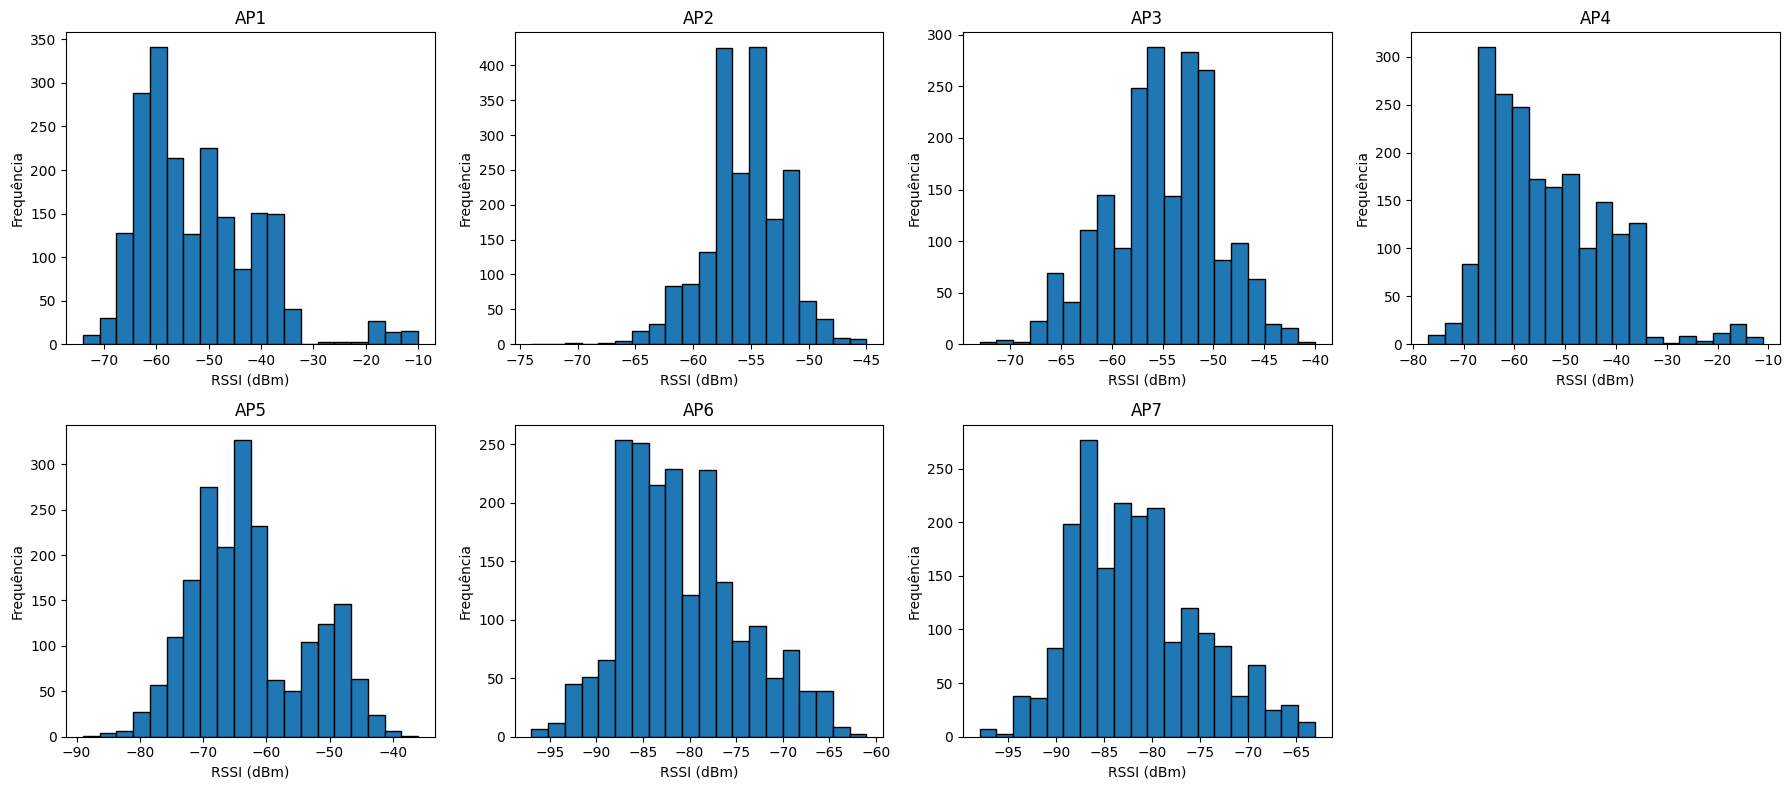

In [6]:
# Criando histogramas para os sete atributos RSSI utilizado IA para para geração dos graficos
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].hist(df[col], bins=20, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel("RSSI (dBm)")
    axes[i].set_ylabel("Frequência")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Essas diferenças podem influenciar diretamente pois atributos com distribuições mais concentradas e estáveis, como o AP2, tendem a fornecer informações mais consistentes para os algoritmos, reduzindo a influência de ruídos e facilitando a identificação das classes. Por outro lado, atributos com maior dispersão, como AP1 e AP4, podem aumentar a capacidade de distinguir diferentes ambientes quando essa variabilidade está relacionada às salas, mas também podem introduzir maior sensibilidade a interferências e valores atípicos. Em algoritmos de clusterização, diferenças muito grandes de dispersão entre os atributos podem influenciar o cálculo das distâncias, tornando recomendável a aplicação de técnicas de normalização ou padronização antes do treinamento.

### <font color='#2D9CDB'>Q5) Analise a distribuição das amostras entre as diferentes salas do dataset. Para isso, apresente a quantidade de exemplos pertencentes a cada classe e construa um gráfico de barras mostrando essa distribuição. Em seguida, informe se o conjunto de dados é balanceado e discuta brevemente como o balanceamento das classes pode influenciar o treinamento e a avaliação de modelos de classificação.</font>

Quantidade de amostras por classe:
Room
1    500
2    500
3    500
4    500
Name: count, dtype: int64


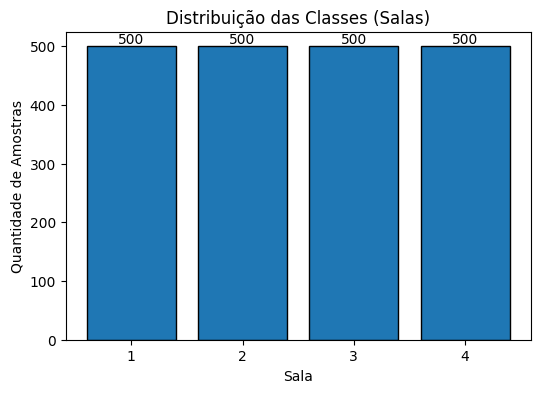


O conjunto de dados é BALANCEADO.


In [7]:
# Contagem das classes
class_counts = df["Room"].value_counts().sort_index()

print("Quantidade de amostras por classe:")
print(class_counts)

# Gráfico de barras
plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values, edgecolor='black')
plt.title("Distribuição das Classes (Salas)")
plt.xlabel("Sala")
plt.ylabel("Quantidade de Amostras")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

# Verificação do balanceamento
if class_counts.nunique() == 1:
    print("\nO conjunto de dados é BALANCEADO.")
else:
    print("\nO conjunto de dados é DESBALANCEADO.")

O balanceamento das classes é uma característica importante no treinamento de modelos de classificação. Em bases balanceadas, os algoritmos tendem a aprender igualmente os padrões de todas as classes, reduzindo o risco de favorecer uma classe específica durante o treinamento.

### <font color='#2D9CDB'>Q6) Divida o dataset em conjuntos de treinamento e teste utilizando 70% das amostras para treinamento e 30% para teste. Utilize estratificação para preservar a proporção das classes em ambos os conjuntos. Em seguida, informe a quantidade de amostras presente em cada conjunto e verifique se a distribuição das classes foi mantida após a divisão.</font>

In [8]:
# Separação entre atributos e variável alvo
X = df.drop(columns=["Room"])
y = df["Room"]

# Divisão 70% treino e 30% teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Quantidade de amostras
print(f"Amostras de treinamento: {len(X_train)}")
print(f"Amostras de teste: {len(X_test)}")

# Distribuição das classes
print("\nDistribuição das classes - Treinamento:")
print(y_train.value_counts().sort_index())

print("\nDistribuição das classes - Teste:")
print(y_test.value_counts().sort_index())

Amostras de treinamento: 1400
Amostras de teste: 600

Distribuição das classes - Treinamento:
Room
1    350
2    350
3    350
4    350
Name: count, dtype: int64

Distribuição das classes - Teste:
Room
1    150
2    150
3    150
4    150
Name: count, dtype: int64


Foi mantida!

# <font color='green'><u><b>Parte 2 - Árvore de Decisão</b></u></font>

<div class="alert alert-info">

As árvores de decisão são algoritmos de aprendizado supervisionado utilizados para tarefas de classificação e regressão. Diferentemente da regressão logística, que utiliza uma equação matemática para modelar a relação entre os atributos e a variável alvo, as árvores de decisão realizam previsões por meio de uma sequência de regras do tipo <i>"se-então"</i>. Durante o treinamento, o algoritmo seleciona os atributos que melhor separam as classes e constrói uma estrutura hierárquica composta por nós e ramificações. Uma das principais vantagens desse método é sua interpretabilidade, pois as decisões tomadas pelo modelo podem ser facilmente visualizadas e compreendidas. Nesta atividade, utilizaremos a implementação <code>DecisionTreeClassifier</code> da biblioteca Scikit-Learn. A documentação oficial pode ser consultada em: <a href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html" target="_blank">https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html</a>.

</div>

### <font color='#2D9CDB'>Q7) Treine uma árvore de decisão para classificar as salas do dataset utilizando os dados de treinamento. Em seguida, informe a profundidade da árvore, o número de nós folha e apresente uma visualização da estrutura aprendida pelo modelo. Com base na árvore obtida, identifique qual atributo foi utilizado no nó raiz e discuta brevemente o que isso indica sobre sua importância para o processo de classificação.</font>

Profundidade da árvore: 13
Número de nós folha: 37
Atributo utilizado no nó raiz: AP1


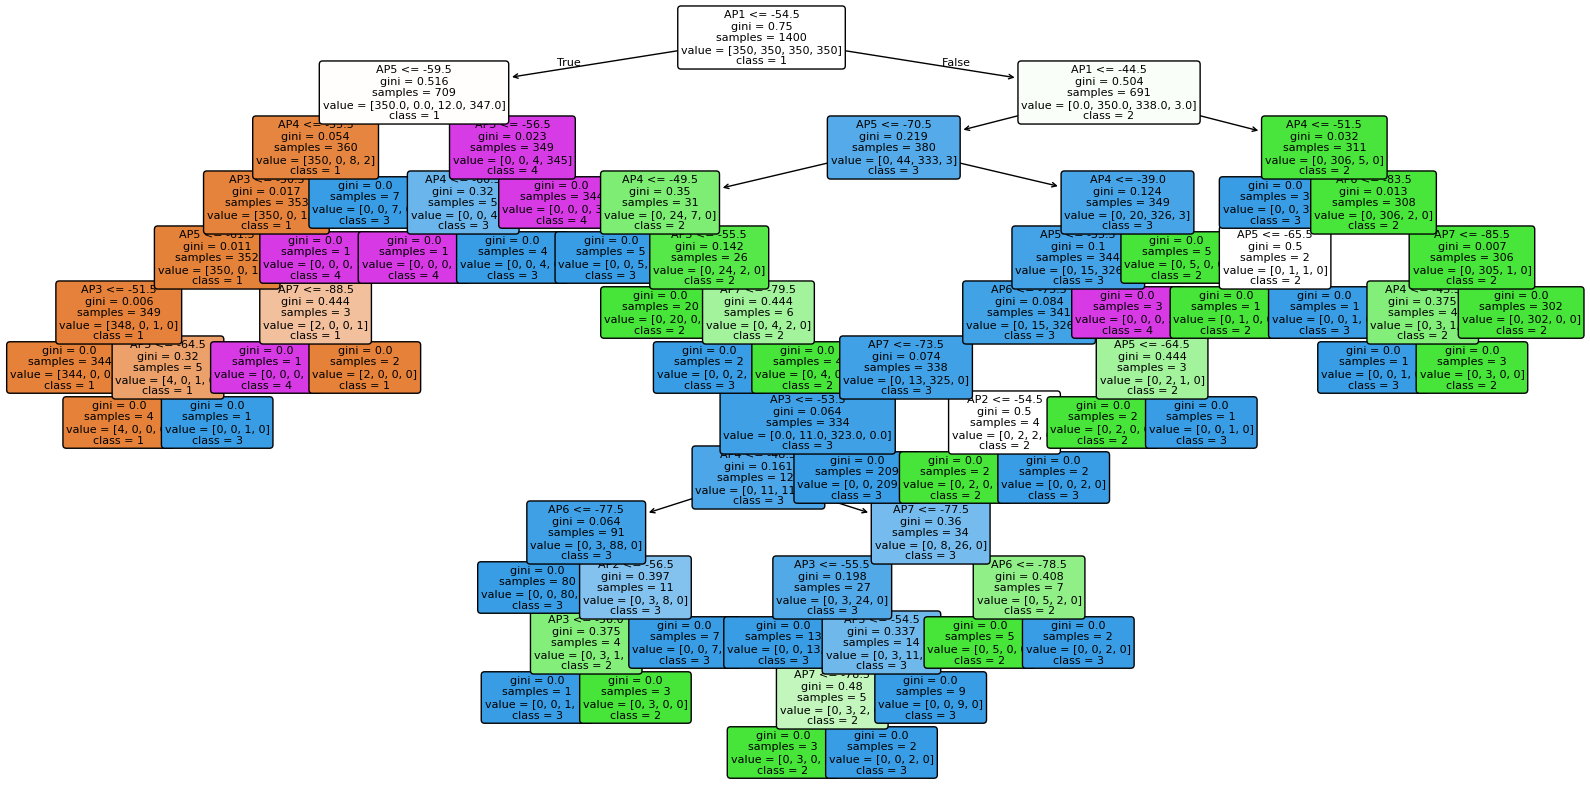

In [9]:
# Treinando a árvore de decisão
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Informações da árvore
print(f"Profundidade da árvore: {dt.get_depth()}")
print(f"Número de nós folha: {dt.get_n_leaves()}")

# Atributo utilizado no nó raiz
root_feature = X.columns[dt.tree_.feature[0]]
print(f"Atributo utilizado no nó raiz: {root_feature}")

# Visualização da árvore
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

O atributo AP1 foi escolhido como nó raiz, realizando a primeira divisão do conjunto de dados utilizando o limiar AP1 ≤ -54,5. Isso indica que o algoritmo considerou esse atributo como o mais informativo para reduzir a impureza dos dados (medida pelo índice de Gini) logo no início do processo de construção da árvore.

### <font color='#2D9CDB'>Q8) Utilize a árvore de decisão treinada para realizar predições sobre o conjunto de teste. Em seguida, calcule a acurácia do modelo e apresente a matriz de confusão correspondente. Com base nos resultados obtidos, analise o desempenho do classificador e identifique quais salas foram classificadas com maior e menor precisão.</font>

Acurácia: 0.9733 (97.33%)

Matriz de confusão:
        Pred 1  Pred 2  Pred 3  Pred 4
Real 1     148       0       1       1
Real 2       0     145       5       0
Real 3       0       6     144       0
Real 4       1       0       2     147


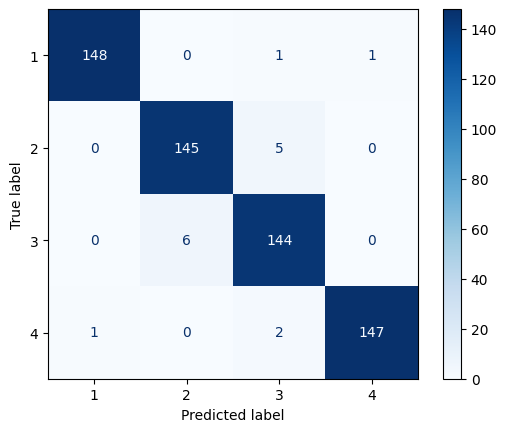

In [10]:
# Predições no conjunto de teste
y_pred = dt.predict(X_test)

# Acurácia
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f} ({acc*100:.2f}%)")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusão:")
print(pd.DataFrame(
    cm,
    index=[f"Real {c}" for c in sorted(y.unique())],
    columns=[f"Pred {c}" for c in sorted(y.unique())]
))

# Exibição gráfica
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)
disp.plot(cmap="Blues")
plt.show()

### <font color='#2D9CDB'>Q9) Treine novas árvores de decisão limitando a profundidade máxima (`max_depth`) aos valores de 1 a 15. Para cada modelo, calcule a acurácia nos conjuntos de treinamento e teste. Em seguida, organize os resultados em uma tabela e construa um gráfico comparando as acurácias obtidas. Com base nos resultados, analise como a profundidade influencia a complexidade e o desempenho do modelo. Por fim, identifique se há evidências de sobreajuste e indique qual profundidade parece oferecer o melhor equilíbrio entre capacidade de aprendizado e generalização.</font>

,Profundidade,Acurácia Treino,Acurácia Teste
0,1,0.500000,0.500000
1,2,0.952857,0.963333
2,3,0.974286,0.970000
3,4,0.982857,0.973333
4,5,0.985714,0.976667
5,6,0.989286,0.973333
6,7,0.990714,0.978333
7,8,0.992143,0.976667
8,9,0.992143,0.980000
9,10,0.994286,0.975000


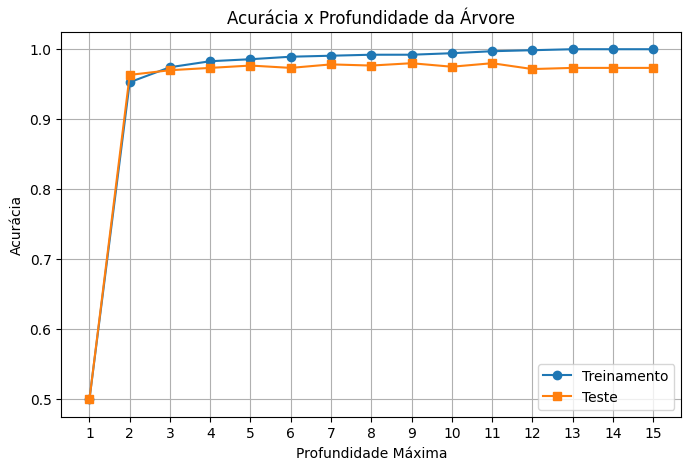

In [11]:
# Listas para armazenar os resultados
depths = range(1, 16)
train_acc = []
test_acc = []

# Treinamento para diferentes profundidades
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Predições
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Acurácias
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Tabela de resultados
results = pd.DataFrame({
    "Profundidade": depths,
    "Acurácia Treino": train_acc,
    "Acurácia Teste": test_acc
})

display(results)

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker='o', label='Treinamento')
plt.plot(depths, test_acc, marker='s', label='Teste')

plt.xlabel("Profundidade Máxima")
plt.ylabel("Acurácia")
plt.title("Acurácia x Profundidade da Árvore")
plt.xticks(depths)
plt.grid(True)
plt.legend()

plt.show()

Há evidências de sobreajuste (overfitting) a partir das maiores profundidades, principalmente entre 12 e 15, quando a acurácia de treinamento atinge praticamente 100%, enquanto a acurácia de teste permanece em torno de 97% a 98%. Isso mostra que a árvore passa a memorizar características específicas do conjunto de treinamento, sem obter ganhos reais sobre dados não vistos.

### <font color='#2D9CDB'>Q10) Utilizando a árvore de decisão treinada, obtenha a importância de cada atributo RSSI por meio da propriedade `feature_importances_`. Em seguida, construa um gráfico de barras ordenando os atributos do mais importante para o menos importante. Com base nos resultados, identifique quais pontos de acesso contribuíram mais para a classificação das salas e discuta por que alguns atributos podem ser mais relevantes do que outros para o problema de localização indoor.</font>

,Atributo,Importância
0,AP1,0.562765
1,AP5,0.365961
2,AP4,0.038710
3,AP7,0.012060
4,AP3,0.008612
5,AP6,0.007260
6,AP2,0.004632


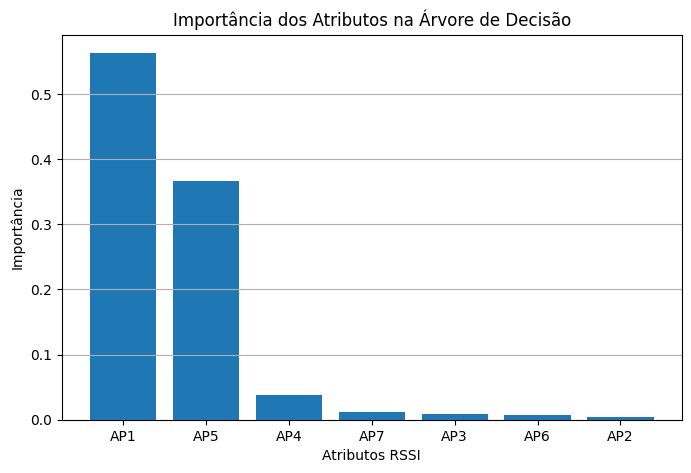

In [12]:
# Importância dos atributos
importancias = pd.DataFrame({
    "Atributo": X.columns,
    "Importância": dt.feature_importances_
})

# Ordenar do mais importante para o menos importante
importancias = importancias.sort_values(
    by="Importância",
    ascending=False
).reset_index(drop=True)

display(importancias)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(importancias["Atributo"], importancias["Importância"])
plt.xlabel("Atributos RSSI")
plt.ylabel("Importância")
plt.title("Importância dos Atributos na Árvore de Decisão")
plt.grid(axis="y")
plt.show()

Esses resultados indicam que os pontos de acesso AP1 e AP5 concentram praticamente toda a informação utilizada pela árvore para distinguir as diferentes salas, totalizando aproximadamente 93% da importância do modelo. Já os atributos AP2, AP3, AP6 e AP7 desempenham papel complementar, sendo utilizados apenas em situações específicas durante a construção da árvore.

# <font color='green'><u><b>Parte 3 - K-Means</b></u></font>

### <font color='#2D9CDB'>Q11) Diferentemente das árvores de decisão, o algoritmo k-Means não utiliza rótulos durante o treinamento. Pesquise brevemente sobre esse método e descreva, em um único parágrafo, o que é clusterização, qual é o objetivo do algoritmo k-Means, o significado de um centroide e como o algoritmo utiliza a distância entre as amostras para formar agrupamentos.</font>

A clusterização é uma técnica de aprendizado de máquina não supervisionado cujo objetivo é agrupar amostras semelhantes sem utilizar rótulos previamente conhecidos. Um dos algoritmos mais utilizados para essa finalidade é o k-Means, que busca particionar os dados em um número pré-definido de grupos (k), de modo que as amostras de um mesmo grupo sejam mais semelhantes entre si do que em relação às amostras de outros grupos. Cada grupo é representado por um centroide, que corresponde ao ponto central do cluster e é calculado como a média dos atributos das amostras pertencentes ao grupo. Durante o treinamento, o algoritmo atribui cada amostra ao centroide mais próximo, geralmente utilizando a distância euclidiana como medida de similaridade. Em seguida, os centroides são recalculados com base nas novas atribuições, repetindo esse processo iterativamente até que as posições dos centroides e a composição dos grupos deixem de sofrer alterações significativas, formando agrupamentos que minimizam a distância entre as amostras e seus respectivos centroides.

### <font color='#2D9CDB'>Q12) Considere os dois atributos mais importantes identificados na Q10. Construa um gráfico de dispersão utilizando essas variáveis, representando as amostras de cada sala com cores distintas e uma legenda apropriada. Com base na visualização obtida, analise a distribuição das amostras e discuta se existem agrupamentos naturais nos dados. Na sua opinião, seria possível identificar as diferentes salas sem utilizar os rótulos originais?</font>

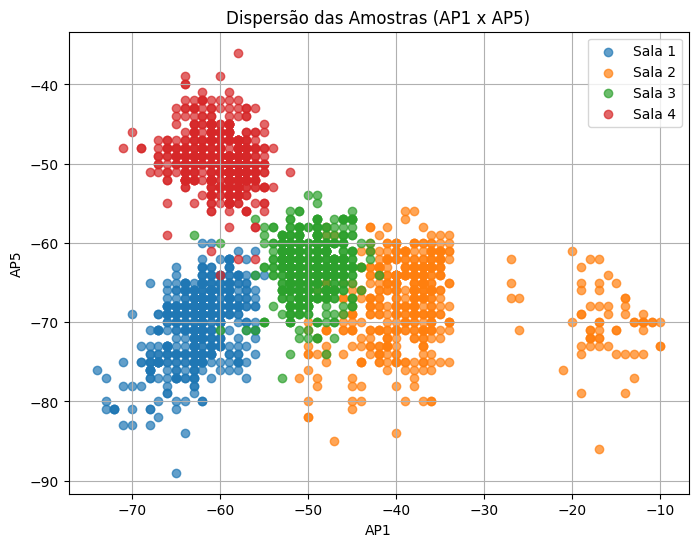

In [13]:
plt.figure(figsize=(8,6))

# Plotar cada sala com uma cor diferente
for sala in sorted(df["Room"].unique()):
    dados = df[df["Room"] == sala]
    plt.scatter(
        dados["AP1"],
        dados["AP5"],
        label=f"Sala {sala}",
        alpha=0.7
    )

plt.xlabel("AP1")
plt.ylabel("AP5")
plt.title("Dispersão das Amostras (AP1 x AP5)")
plt.legend()
plt.grid(True)

plt.show()

Com base nessa visualização, é possível afirmar que existem agrupamentos naturais nos dados. Dessa forma, mesmo sem utilizar os rótulos originais, seria possível identificar grupos correspondentes às diferentes salas utilizando algoritmos de aprendizado não supervisionado, como o k-Means.

### <font color='#2D9CDB'>Q13) Antes de aplicar o algoritmo k-Means, é necessário definir o número de clusters (*k*). Utilize o Método do Cotovelo (Elbow Method) para avaliar valores de *k* entre 1 e 10. Para cada valor, calcule a inércia do modelo e construa um gráfico relacionando o número de clusters e a inércia obtida. Com base no gráfico, identifique o valor de *k* que parece mais adequado para este conjunto de dados e justifique sua escolha.</font>

Valores de Inércia:
k = 1: 934746.06
k = 2: 499806.15
k = 3: 366254.90
k = 4: 246771.59
k = 5: 204311.75
k = 6: 189041.64
k = 7: 178524.33
k = 8: 168249.43
k = 9: 161434.65
k = 10: 155014.87


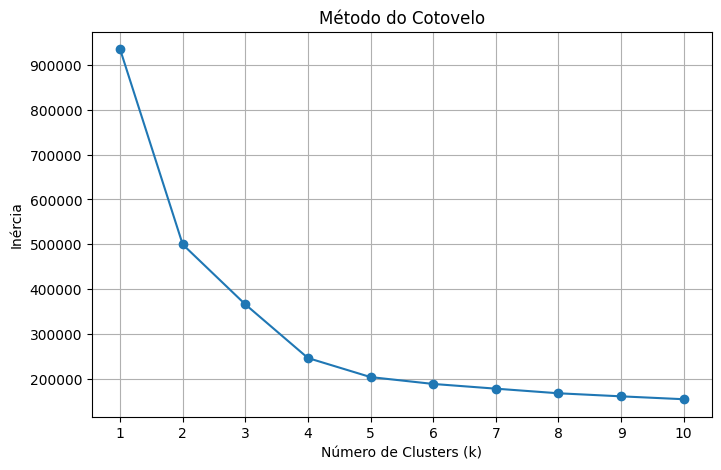

In [14]:
# Calculando a inércia para diferentes valores de k
ks = range(1, 11)
inertias = []

for k in ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Exibir valores de inércia
print("Valores de Inércia:")
for k, inertia in zip(ks, inertias):
    print(f"k = {k}: {inertia:.2f}")

# Gráfico do Método do Cotovelo
plt.figure(figsize=(8,5))
plt.plot(ks, inertias, marker='o')

plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia")
plt.xticks(ks)
plt.grid(True)

plt.show()

Escolho o k = 4 pois é o que melhor representa o "cotovelo" da curva, sendo considerado o número mais adequado de clusters para este conjunto de dados. Essa escolha é coerente com a estrutura do problema, uma vez que o dataset possui quatro salas distintas, sugerindo naturalmente a existência de quatro agrupamentos principais.

### <font color='#2D9CDB'>Q14) Utilizando o valor de *k* identificado na Q13, treine um modelo k-Means empregando apenas os atributos AP1 e AP5. Em seguida, apresente as coordenadas dos centroides encontrados e construa um gráfico de dispersão mostrando as amostras coloridas de acordo com o cluster atribuído pelo algoritmo. Destaque também os centroides no gráfico. Com base nos resultados, analise a qualidade dos agrupamentos obtidos.</font>

Centroides encontrados:


,AP1,AP5
0,-60.207243,-49.372233
1,-34.801008,-67.821159
2,-62.377470,-70.424901
3,-48.931667,-63.638333


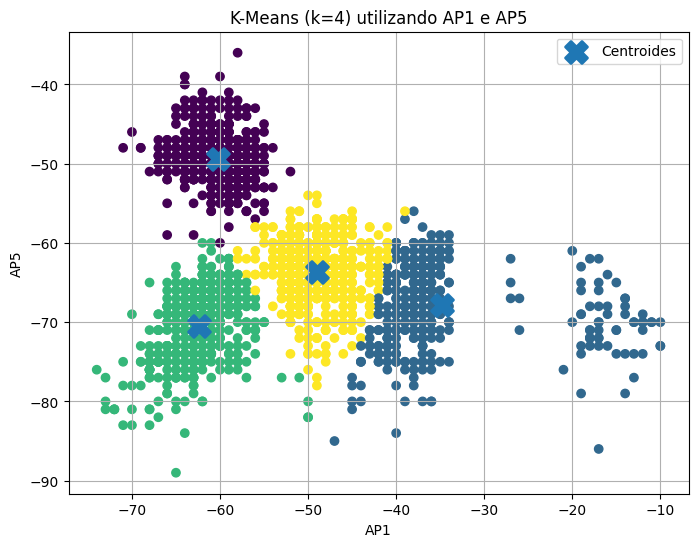

In [15]:
# Selecionando apenas AP1 e AP5
X_kmeans = df[["AP1", "AP5"]]

# Treinando o K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_kmeans)

# Coordenadas dos centroides
centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["AP1", "AP5"]
)

print("Centroides encontrados:")
display(centroides)

# Gráfico
plt.figure(figsize=(8,6))

plt.scatter(
    X_kmeans["AP1"],
    X_kmeans["AP5"],
    c=clusters
)

plt.scatter(
    centroides["AP1"],
    centroides["AP5"],
    marker="X",
    s=250,
    linewidths=2,
    label="Centroides"
)

plt.xlabel("AP1")
plt.ylabel("AP5")
plt.title("K-Means (k=4) utilizando AP1 e AP5")
plt.legend()
plt.grid(True)

plt.show()

De maneira geral, os resultados indicam que o algoritmo k-Means foi capaz de identificar corretamente a estrutura natural dos dados utilizando apenas dois atributos. A boa distribuição dos centroides e a formação de grupos compactos demonstram que AP1 e AP5 possuem elevado poder discriminativo para representar a localização das amostras no ambiente indoor.

### <font color='#2D9CDB'>Q15) Compare os clusters encontrados pelo k-Means com as salas reais do dataset. Para isso, construa uma <a href="https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html">tabela de contingência</a> relacionando cada sala aos clusters atribuídos pelo algoritmo. Em seguida, identifique qual cluster representa predominantemente cada sala e calcule a porcentagem de amostras associadas a esse agrupamento. Com base nos resultados, discuta quais salas foram mais facilmente identificadas pelo algoritmo e quais apresentaram maior grau de confusão com outros grupos.</font>

In [16]:
# Tabela de contingência (Sala x Cluster)
tabela = pd.crosstab(
    df["Room"],
    clusters,
    rownames=["Sala"],
    colnames=["Cluster"]
)

print("Tabela de Contingência:")
display(tabela)

# Porcentagem por sala
print("\nCluster predominante por sala:\n")

for sala in tabela.index:
    cluster_pred = tabela.loc[sala].idxmax()
    qtd = tabela.loc[sala].max()
    perc = qtd / tabela.loc[sala].sum() * 100

    print(
        f"Sala {sala}: Cluster {cluster_pred} "
        f"({qtd} amostras - {perc:.2f}%)"
    )

Tabela de Contingência:


Cluster,0,1,2,3
Sala,,,,
1,0,0,493,7
2,0,396,4,100
3,3,0,7,490
4,494,0,2,4



Cluster predominante por sala:

Sala 1: Cluster 2 (493 amostras - 98.60%)
Sala 2: Cluster 1 (396 amostras - 79.20%)
Sala 3: Cluster 3 (490 amostras - 98.00%)
Sala 4: Cluster 0 (494 amostras - 98.80%)


A sala mais facilmente identificada: Sala 4 (98,80%).
                                                                               Também muito bem identificadas: Sala 1 (98,60%) e Sala 3 (98,00%).
Sala com maior confusão: Sala 2 (79,20%), principalmente confundida com a Sala 3.
                                                                                O resultado confirma as análises das questões anteriores: os atributos AP1 e AP5 permitem uma excelente separação dos dados, mas existe uma região de sobreposição entre as Salas 2 e 3, o que explica os erros observados tanto no k-Means quanto na Árvore de Decisão.

# <font color='green'><u><b>Parte 4 - Detecção de Anomalias</b></u></font>

### <font color='#2D9CDB'>Q16) Uma aplicação comum de algoritmos de clusterização é a detecção de anomalias. Em geral, amostras localizadas muito longe do centroide de seu cluster podem representar comportamentos incomuns ou situações atípicas. Utilizando os dois atributos mais importantes identificados na Q10, calcule a distância euclidiana de cada amostra ao centroide do cluster ao qual ela foi atribuída pelo k-Means. Em seguida, apresente um histograma dessas distâncias e informe os valores mínimo, máximo, médio e o desvio padrão observados. Com base nos resultados, discuta o que essas distâncias revelam sobre a compactação dos clusters encontrados.</font>

Distância mínima: 0.2675
Distância máxima: 25.4430
Distância média: 5.2355
Desvio padrão: 3.6667


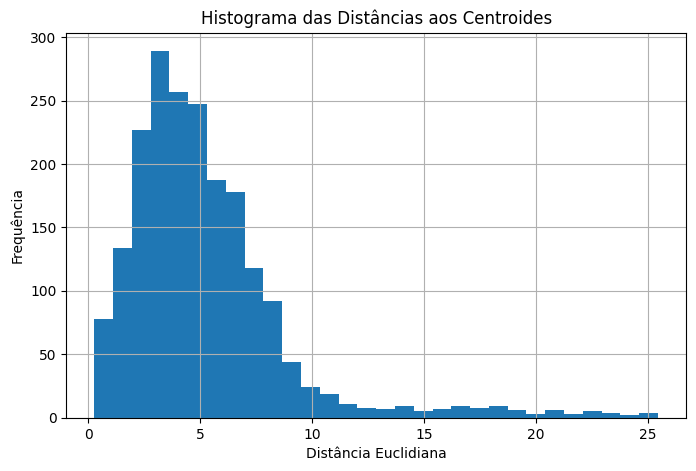

In [17]:
# Dados utilizados no K-Means
X_kmeans = df[["AP1", "AP5"]].values

# Distância de cada amostra ao centroide do seu cluster
distancias = np.linalg.norm(
    X_kmeans - kmeans.cluster_centers_[clusters],
    axis=1
)

# Estatísticas
print(f"Distância mínima: {distancias.min():.4f}")
print(f"Distância máxima: {distancias.max():.4f}")
print(f"Distância média: {distancias.mean():.4f}")
print(f"Desvio padrão: {distancias.std():.4f}")

# Histograma
plt.figure(figsize=(8,5))
plt.hist(distancias, bins=30)

plt.title("Histograma das Distâncias aos Centroides")
plt.xlabel("Distância Euclidiana")
plt.ylabel("Frequência")
plt.grid(True)

plt.show()

Esses resultados confirmam que os clusters obtidos pelo k-Means são compactos e bem estruturados, enquanto as poucas amostras muito distantes dos centroides representam candidatos naturais à detecção de anomalias no ambiente de localização indoor.

### <font color='#2D9CDB'>Q17) Considere que amostras muito distantes do centroide de seu cluster podem ser classificadas como potenciais anomalias. Utilize o percentil de 95% das distâncias calculadas na Q16 como limiar de detecção. Em seguida, identifique todas as amostras cuja distância ao centroide seja superior a esse valor, informe quantas anomalias foram encontradas e apresente as cinco amostras mais distantes de seus respectivos centroides. Com base nos resultados, discuta se o critério adotado parece adequado para identificar observações atípicas.</font>

In [18]:
# Percentil de 95%
limiar = np.percentile(distancias, 95)

print(f"Limiar (percentil de 95%): {limiar:.4f}")

# Criar DataFrame com informações
resultado = df.copy()

resultado["Cluster"] = clusters
resultado["Distancia"] = distancias

# Selecionar anomalias
anomalias = resultado[resultado["Distancia"] > limiar]

print(f"\nQuantidade de anomalias: {len(anomalias)}")

print("\nCinco amostras mais distantes dos centroides:")
display(
    anomalias.sort_values(
        by="Distancia",
        ascending=False
    ).head(5)
)

Limiar (percentil de 95%): 11.6104

Quantidade de anomalias: 100

Cinco amostras mais distantes dos centroides:


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room,Cluster,Distancia
609,-17,-63,-65,-27,-86,-72,-74,2,1,25.442998
769,-10,-57,-57,-36,-73,-82,-72,2,1,25.335950
873,-10,-58,-62,-20,-73,-76,-74,2,1,25.335950
870,-10,-58,-54,-18,-70,-72,-73,2,1,24.896532
932,-11,-59,-60,-27,-70,-74,-71,2,1,23.900529


Essa sequência de resultados demonstra consistência entre todas as análises realizadas: a Sala 2 é a que apresenta maior dispersão dos valores de RSSI, maior dificuldade de agrupamento e concentra as principais observações classificadas como potenciais anomalias.

### <font color='#2D9CDB'>Q18) Construa um gráfico de dispersão utilizando os dois atributos empregados pelo k-Means e destaque as anomalias identificadas na Q17. Represente também os centroides dos clusters. Com base na visualização obtida, avalie se as amostras classificadas como anômalas encontram-se em regiões afastadas dos centroides e discuta se os resultados são coerentes com o critério de detecção adotado.</font>

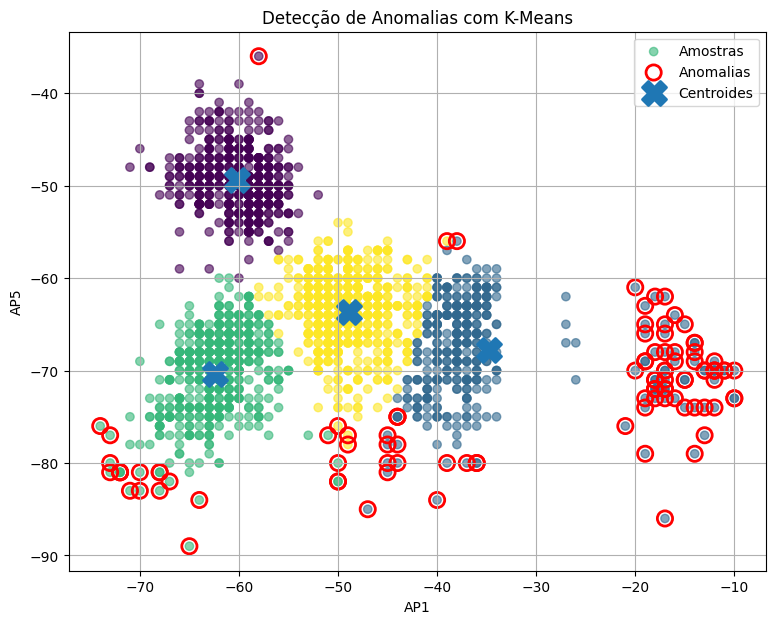

In [19]:
plt.figure(figsize=(9, 7))

# Amostras normais coloridas pelo cluster
plt.scatter(
    resultado["AP1"],
    resultado["AP5"],
    c=resultado["Cluster"],
    alpha=0.6,
    label="Amostras"
)

# Anomalias destacadas
plt.scatter(
    anomalias["AP1"],
    anomalias["AP5"],
    facecolors="none",
    edgecolors="red",
    s=120,
    linewidths=2,
    label="Anomalias"
)

# Centroides
plt.scatter(
    centroides["AP1"],
    centroides["AP5"],
    marker="X",
    s=300,
    linewidths=2,
    label="Centroides"
)

plt.title("Detecção de Anomalias com K-Means")
plt.xlabel("AP1")
plt.ylabel("AP5")
plt.legend()
plt.grid(True)

plt.show()

Essa sequência de resultados demonstra que a estratégia adotada para detecção de anomalias é consistente: as observações classificadas como anômalas são justamente aquelas localizadas nas regiões mais distantes dos centroides dos clusters, corroborando tanto a análise estatística quanto a visualização gráfica.

### <font color='#2D9CDB'>Q19) O limiar utilizado para detectar anomalias influencia diretamente a quantidade de observações classificadas como atípicas. Repita o procedimento da Q17 utilizando os percentis 90%, 95% e 99% das distâncias aos centroides. Para cada caso, registre o valor do limiar e o número de anomalias detectadas. Organize os resultados em uma tabela e discuta como a escolha do percentil afeta a sensibilidade do detector de anomalias.</font>

In [20]:
percentis = [90, 95, 99]
resultados = []

for p in percentis:
    limiar = np.percentile(distancias, p)
    qtd_anomalias = np.sum(distancias > limiar)

    resultados.append({
        "Percentil": f"{p}%",
        "Limiar": round(limiar, 4),
        "Anomalias": int(qtd_anomalias)
    })

tabela_resultados = pd.DataFrame(resultados)

print("Resultados:")
display(tabela_resultados)

Resultados:


,Percentil,Limiar,Anomalias
0,90%,8.5771,200
1,95%,11.6104,100
2,99%,20.8174,20


Os resultados evidenciam um comportamento esperado: quanto maior o percentil, maior é o limiar de distância e menor é o número de amostras classificadas como anômalas. Assim, a escolha do percentil representa um compromisso entre sensibilidade e especificidade. No contexto deste problema, o percentil de 95% oferece o melhor equilíbrio, permitindo identificar observações realmente incomuns sem gerar um número excessivo de falsas detecções.

# <font color='green'><u><b>Parte 5 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q20) Ao longo desta atividade foram exploradas técnicas de aprendizado supervisionado (Árvores de Decisão) e não supervisionado (k-Means), além de uma abordagem simples para detecção de anomalias baseada na distância aos centroides. Compare essas três aplicações quanto aos seus objetivos, à utilização de rótulos durante o treinamento, aos resultados produzidos e às situações em que cada uma delas é mais adequada. Por fim, discuta como essas técnicas poderiam ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi.</font>

Essas três técnicas são complementares e podem ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi. Inicialmente, o k-Means pode ser empregado para explorar os dados e identificar agrupamentos naturais, mesmo quando não existem rótulos disponíveis. Após a obtenção de dados rotulados, uma Árvore de Decisão pode ser treinada para realizar a classificação automática das salas com alta precisão e boa interpretabilidade. Paralelamente, a análise das distâncias aos centroides pode funcionar como um mecanismo de monitoramento, detectando leituras incomuns que possam indicar interferências no sinal, mudanças no ambiente, falhas de sensores ou até a presença de dispositivos em posições não previstas. Assim, a combinação dessas técnicas pode criar um sistema mais completo e robusto.